# IMPORT

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from utils import get_metadata 
from configuration import *
import seaborn as sns
from analyse_memory import *
from scipy.stats import median_abs_deviation

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
c:\Users\marion.walter\anaconda3\envs\Etude1\Lib\site-packages\rpy2\rinterface\__init__.py:1211: UserWarning: Environment variable "4" redefined by R and overriding existing variable. Current: "C:\ProgramData", R: ""1""
  warnings.warn(
c:\Users\marion.walter\anaconda3\envs\Etude1\Lib\site-packages\rpy2\rinterface\__init__.py:1211: UserWarning: Environment variable "5" redefined by R and overriding existing variable. Current: "C:\Users\marion.walter\AppData\Roaming", R: "C:\Program Files\Common Files"
  warnings.warn(
c:\Users\marion.walter\anaconda3\envs\Etude1\Lib\site-packages\rpy2\rinterface\__init__.py:1211: UserWarning: Environment variable "6" redefined by R and overriding existing variable. Current: "true", R: "11920"
  warnings.warn(
c:\Users\marion.walter\anaconda3\envs\Etude1\Lib\site-packages\rpy2\rinterface\__init__.py:1211: UserWarning: Environment variable

# CODE

## Participants description

In [2]:
meta_data = get_metadata()
meta_data

,Code pseudonymisation,subject,age,birthdate,gender,laterality,session1_date,session2_date,time_between_session,stimulus_choice,group,R1,R2,order,DFS_total
0,MB1,sub-01,28,19/11/1995,F,D,29/10/2024,05/11/2024,7,Géranium,O-,Distraction,Rest,D-R,26
1,FG7,sub-07,28,27/11/1995,F,D,14/11/2024,15/11/2024,1,Lavande,O-,Rest,Distraction,R-D,22
2,CR10,sub-10,24,09/01/2000,F,G,22/11/2024,25/11/2024,3,Lavande,O-,Distraction,Rest,D-R,43
3,MG12,sub-12,29,25/08/1995,M,D,27/11/2024,04/12/2024,7,Marjolaine,O-,Rest,Distraction,R-D,43
4,FL14,sub-14,53,09/09/1971,F,D,29/11/2024,06/12/2024,7,Cèdre,O-,Rest,Distraction,R-D,41
5,LL16,sub-16,23,02/04/2001,F,D,09/12/2024,10/12/2024,1,Rose,O-,Rest,Distraction,R-D,43
6,CT19,sub-19,27,25/11/1997,M,D,11/12/2024,12/12/2024,1,Petit Grain,O-,Rest,Distraction,R-D,45
7,EB20,sub-20,20,20/10/2004,F,D,11/12/2024,16/12/2024,5,Petit Grain,O-,Distraction,Rest,D-R,52
8,ID22,sub-22,34,16/07/1990,F,D,16/12/2024,17/12/2024,1,Petit Grain,O-,Distraction,Rest,D-R,43
9,CB23,sub-23,48,07/09/1976,F,G,06/01/2025,03/02/2025,28,Orange,O-,Rest,Distraction,R-D,52


In [3]:
meta_data.describe()

,age,DFS_total
count,30.000000,30.000000
mean,29.300000,42.433333
std,10.462247,9.807398
min,20.000000,22.000000
25%,23.000000,34.500000
50%,26.500000,43.000000
75%,29.000000,47.750000
max,57.000000,59.000000


<Axes: xlabel='age', ylabel='Count'>

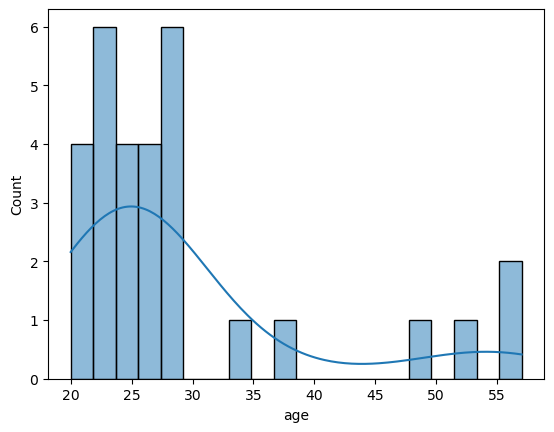

In [3]:
sns.histplot(meta_data['age'], bins=20, kde=True)

<Axes: xlabel='DFS_total', ylabel='Count'>

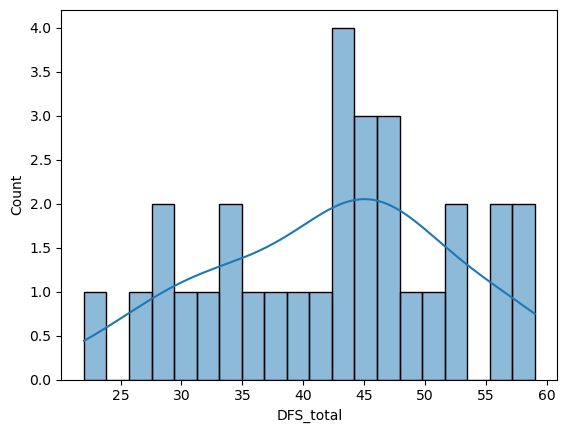

In [9]:
sns.histplot(meta_data['DFS_total'], bins=20, kde=True)

In [10]:
median_DFS = np.round(meta_data['DFS_total'].median(), 2)
mad_DFS = np.round(median_abs_deviation(meta_data['DFS_total'], scale='normal'), 2)

print(f'******************************** Median (MAD) of DFS scores ******************************** \n- {median_DFS} ({mad_DFS})')

******************************** Median (MAD) of DFS scores ******************************** 
- 43.0 (10.38)


### get time between sessions

In [15]:
meta_data['Date1'] = pd.to_datetime(meta_data['session1_date'], dayfirst=True)
meta_data['Date2'] = pd.to_datetime(meta_data['session2_date'], dayfirst=True)
meta_data['Time_Difference'] = meta_data['Date2'] - meta_data['Date1']
meta_data['Days_Difference'] = meta_data['Time_Difference'].dt.total_seconds() / (24 * 3600)
meta_data


,Code pseudonymisation,subject,age,birthdate,gender,laterality,session1_date,session2_date,time_between_session,stimulus_choice,group,R1,R2,order,DFS_total,Date1,Date2,Time_Difference,Days_Difference
0,MB1,sub-01,28,19/11/1995,F,D,29/10/2024,05/11/2024,"7,00",Géranium,O-,Distraction,Rest,D-R,26,2024-10-29,2024-11-05,7 days,7.0
1,FG7,sub-07,28,27/11/1995,F,D,14/11/2024,15/11/2024,"1,00",Lavande,O-,Rest,Distraction,R-D,22,2024-11-14,2024-11-15,1 days,1.0
2,CR10,sub-10,24,09/01/2000,F,G,22/11/2024,25/11/2024,"3,00",Lavande,O-,Distraction,Rest,D-R,43,2024-11-22,2024-11-25,3 days,3.0
3,MG12,sub-12,29,25/08/1995,M,D,27/11/2024,04/12/2024,"7,00",Marjolaine,O-,Rest,Distraction,R-D,43,2024-11-27,2024-12-04,7 days,7.0
4,FL14,sub-14,53,09/09/1971,F,D,29/11/2024,06/12/2024,"7,00",Cèdre,O-,Rest,Distraction,R-D,41,2024-11-29,2024-12-06,7 days,7.0
5,LL16,sub-16,23,02/04/2001,F,D,09/12/2024,10/12/2024,"1,00",Rose,O-,Rest,Distraction,R-D,43,2024-12-09,2024-12-10,1 days,1.0
6,CT19,sub-19,27,25/11/1997,M,D,11/12/2024,12/12/2024,"1,00",Petit Grain,O-,Rest,Distraction,R-D,45,2024-12-11,2024-12-12,1 days,1.0
7,EB20,sub-20,20,20/10/2004,F,D,11/12/2024,16/12/2024,"5,00",Petit Grain,O-,Distraction,Rest,D-R,52,2024-12-11,2024-12-16,5 days,5.0
8,ID22,sub-22,34,16/07/1990,F,D,16/12/2024,17/12/2024,"1,00",Petit Grain,O-,Distraction,Rest,D-R,43,2024-12-16,2024-12-17,1 days,1.0
9,CB23,sub-23,48,07/09/1976,F,G,06/01/2025,03/02/2025,"28,00",Orange,O-,Rest,Distraction,R-D,52,2025-01-06,2025-02-03,28 days,28.0


In [ ]:
meta_data['Days_Difference'] = meta_data['Time_Difference'].dt.total_seconds() / (24 * 3600)

median_day = np.round(meta_data['Days_Difference'].median(), 2)
mad_day = np.round(median_abs_deviation(meta_data['Days_Difference'], scale='normal'), 2)

mean_day = np.round(meta_data['Days_Difference'].mean(), 2)
sd_day = np.round(meta_data['Days_Difference'].std(), 2)

print(f'******************************** Median (MAD) of number of day between session 1 and 2 ******************************** \n- {median_day} ({mad_day})')

******************************** Median (MAD) of number of day between session 1 and 2 ******************************** 
- 3.0 (2.97)


In [20]:
meta_data.describe()

,age,DFS_total,Date1,Date2,Time_Difference,Days_Difference
count,30.000000,30.000000,30,30,30,30.000000
mean,29.300000,42.433333,2025-01-20 11:12:00,2025-01-25 03:12:00,4 days 16:00:00,4.666667
min,20.000000,22.000000,2024-10-29 00:00:00,2024-11-05 00:00:00,1 days 00:00:00,1.000000
25%,23.000000,34.500000,2024-12-12 06:00:00,2024-12-16 06:00:00,1 days 00:00:00,1.000000
50%,26.500000,43.000000,2025-01-27 12:00:00,2025-02-04 00:00:00,3 days 00:00:00,3.000000
75%,29.000000,47.750000,2025-02-24 18:00:00,2025-03-02 12:00:00,6 days 18:00:00,6.750000
max,57.000000,59.000000,2025-03-21 00:00:00,2025-03-28 00:00:00,28 days 00:00:00,28.000000
std,10.462247,9.807398,NaN,NaN,5 days 14:02:48.575795013,5.585284
